
INFORMACJE O ZBIORZE DANYCH:
Całkowita liczba próbek (po czyszczeniu): 4316
Liczba próbek w zbiorze treningowym (80%): 3452
Liczba próbek w zbiorze testowym (20%): 864

Rozpoczęto trenowanie modeli na danych od 2026-04-06 do 2026-04-20...

WYNIKI PORÓWNANIA MODELI (ZBIÓR TESTOWY):
            Model    MAE   RMSE     R2
 Regresja Liniowa  41.17  58.47 0.9650
    Random Forest  47.57  67.84 0.9529
Gradient Boosting  48.87  73.67 0.9444
              KNN 119.53 160.24 0.7370



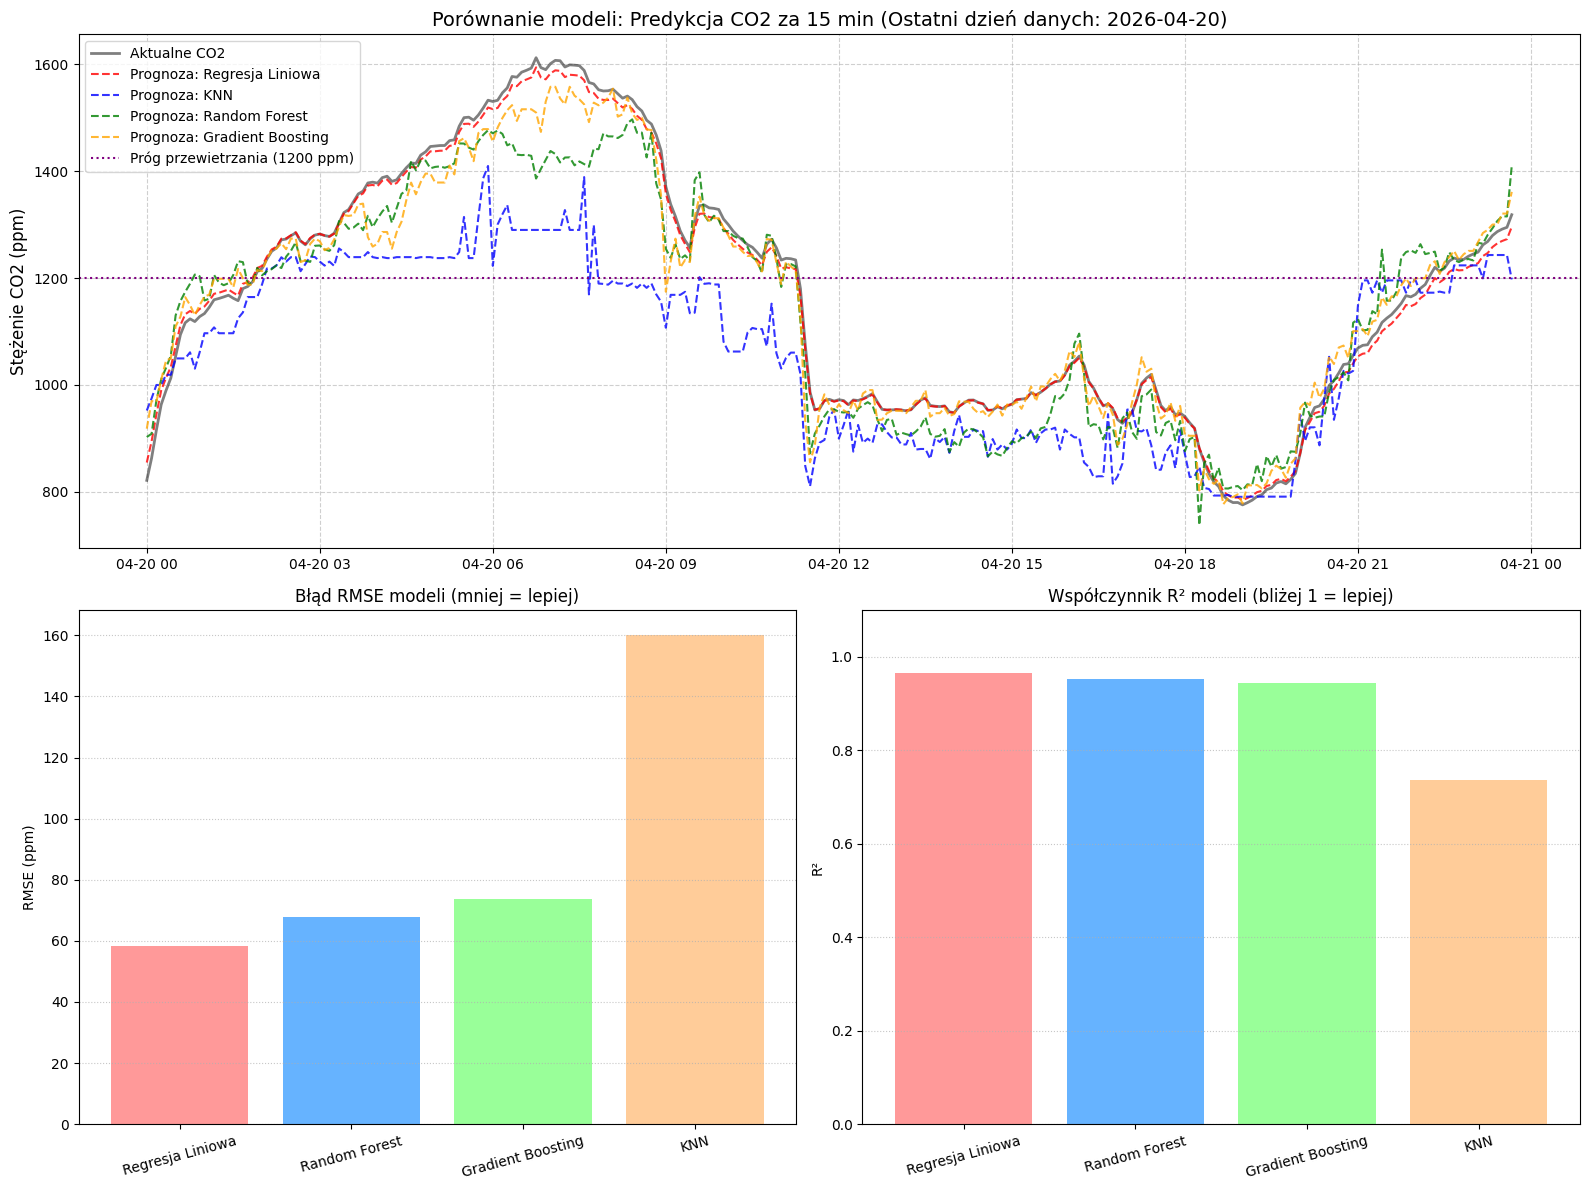

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def compare_models():
    db_path = '/content/sensors.db'
    prog_co2 = 1200

    conn = sqlite3.connect(db_path)
    end_date = datetime(2026, 4, 20)
    date_limit = (end_date - timedelta(days=14)).strftime('%Y-%m-%d')
    end_date_str = end_date.strftime('%Y-%m-%d 23:59:59')

    query = f"SELECT timestamp, co2, temp, hum FROM readings WHERE timestamp > '{date_limit}' AND timestamp <= '{end_date_str}'"
    df = pd.read_sql_query(query, conn)
    conn.close()

    if len(df) < 100:
        print(f"Zbyt mało danych do trenowania modelu. Znaleziono tylko {len(df)} rekordów.")
        return

    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').set_index('timestamp')
    df_res = df.resample('5min').mean().interpolate()

    df_res['target_co2'] = df_res['co2'].shift(-3)
    df_res['hour'] = df_res.index.hour
    df_res['day_of_week'] = df_res.index.dayofweek
    df_res['co2_trend'] = df_res['co2'].diff()
    df_model = df_res.dropna()
    features = ['co2', 'temp', 'hum', 'hour', 'day_of_week', 'co2_trend']
    X = df_model[features]
    y = df_model['target_co2']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    print("\n" + "="*70)
    print("INFORMACJE O ZBIORZE DANYCH:")
    print("="*70)
    print(f"Całkowita liczba próbek (po czyszczeniu): {len(df_model)}")
    print(f"Liczba próbek w zbiorze treningowym (80%): {len(X_train)}")
    print(f"Liczba próbek w zbiorze testowym (20%): {len(X_test)}")
    print("="*70 + "\n")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)


    models = {
        "Regresja Liniowa": LinearRegression(),
        "KNN": KNeighborsRegressor(n_neighbors=5),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
    }

    results = []

    test_results_df = X_test.copy()
    test_results_df['target_co2'] = y_test

    print(f"Rozpoczęto trenowanie modeli na danych od {date_limit} do 2026-04-20...")
    for name, model in models.items():
        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

        test_results_df[f'pred_{name}'] = y_pred

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results.append({
            'Model': name,
            'MAE': round(mae, 2),
            'RMSE': round(rmse, 2),
            'R2': round(r2, 4)
        })

    # WYNIKI
    results_df = pd.DataFrame(results)

    print("\n" + "="*70)
    print("WYNIKI PORÓWNANIA MODELI (ZBIÓR TESTOWY):")
    print("="*70)
    print(results_df.sort_values(by='RMSE').to_string(index=False))
    print("="*70 + "\n")

    # WIZUALIZACJA
    data_wyboru = test_results_df.index.max().strftime('%Y-%m-%d')
    widok = test_results_df.loc[data_wyboru]

    if not widok.empty:
        plt.figure(figsize=(16, 12))

        plt.subplot(2, 1, 1)
        plt.plot(widok.index, widok['co2'], label='Aktualne CO2', color='black', linewidth=2, alpha=0.5)

        colors = ['red', 'blue', 'green', 'orange']
        for (name, _), color in zip(models.items(), colors):
            plt.plot(widok.index, widok[f'pred_{name}'], label=f'Prognoza: {name}', linestyle='--', color=color, alpha=0.8)

        plt.axhline(y=prog_co2, color='purple', linestyle=':', label=f'Próg przewietrzania ({prog_co2} ppm)')
        plt.title(f'Porównanie modeli: Predykcja CO2 za 15 min (Ostatni dzień danych: {data_wyboru})', fontsize=14)
        plt.ylabel('Stężenie CO2 (ppm)', fontsize=12)
        plt.legend(loc='upper left', frameon=True)
        plt.grid(True, linestyle='--', alpha=0.6)

        plt.subplot(2, 2, 3)
        sorted_results = results_df.sort_values('RMSE')
        plt.bar(sorted_results['Model'], sorted_results['RMSE'], color=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
        plt.title('Błąd RMSE modeli (mniej = lepiej)', fontsize=12)
        plt.ylabel('RMSE (ppm)', fontsize=10)
        plt.xticks(rotation=15)
        plt.grid(axis='y', linestyle=':', alpha=0.7)

        plt.subplot(2, 2, 4)
        plt.bar(sorted_results['Model'], sorted_results['R2'], color=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
        plt.title('Współczynnik R² modeli (bliżej 1 = lepiej)', fontsize=12)
        plt.ylabel('R²', fontsize=10)
        plt.ylim(0, 1.1)
        plt.xticks(rotation=15)
        plt.grid(axis='y', linestyle=':', alpha=0.7)

        plt.tight_layout()
        plt.show()
    else:
        print("Błąd generowania wykresu: brak danych na wybrany dzień.")

if __name__ == "__main__":
    compare_models()